In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
Data = {'Country': ['USA','Canada','Germany','UK','France'],
        'GDP': [45000,42000,52000,49000,47000]}

df = pd.DataFrame(Data)
#df = pd.DataFrame(Data,columns=['Country','GDP_STATE'])

In [3]:
df.head()

,Country,GDP
0,USA,45000
1,Canada,42000
2,Germany,52000
3,UK,49000
4,France,47000


In [4]:
x = df['Country'].values
y = df['GDP'].values

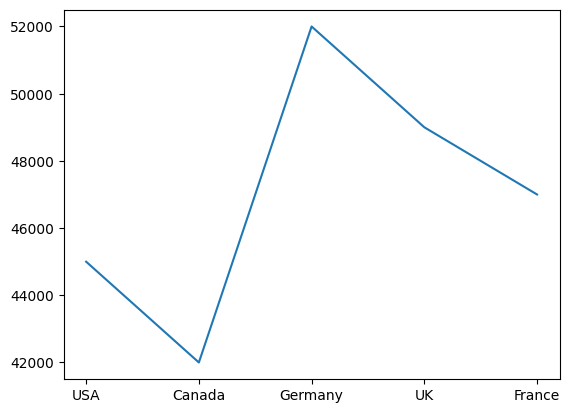

In [5]:
plt.plot(x,y)

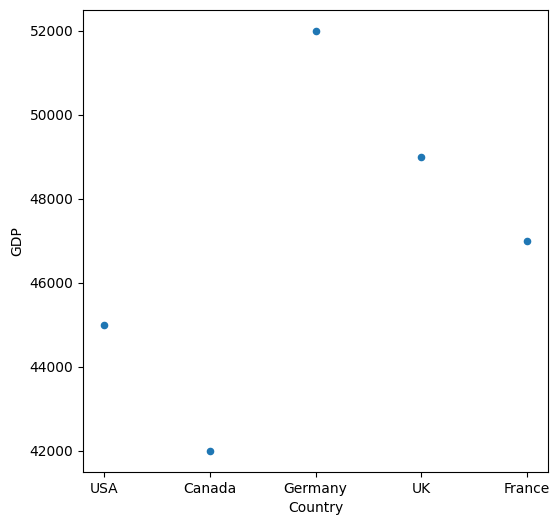

In [6]:
df.plot(x ='Country',y='GDP', figsize=(6, 6), kind = 'scatter');
#plt.show()

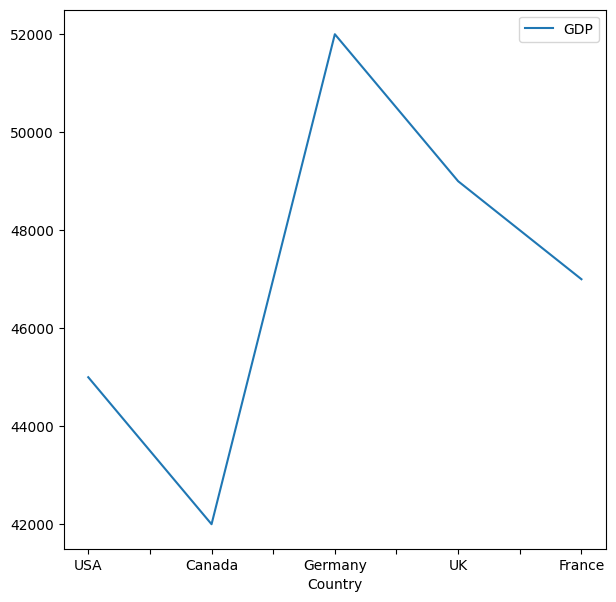

In [ ]:
df.plot(x ='Country',y='GDP', figsize=(7, 7),kind = 'line');
#plt.show()

In [7]:
Data = {'Tasks': [300,500,700]}
df = pd.DataFrame(Data,columns=['Tasks'])

In [8]:
df.head()

,Tasks
0,300
1,500
2,700


In [9]:
df = pd.DataFrame(Data,columns=['Tasks'],
                  index = ['Tasks Pending','Tasks Ongoing','Tasks Completed'])
df.head()

,Tasks
Tasks Pending,300
Tasks Ongoing,500
Tasks Completed,700


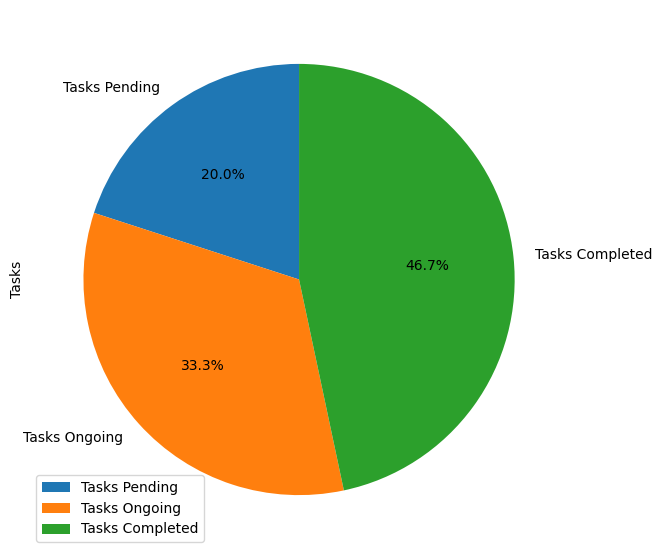

In [10]:
df.plot(y='Tasks',figsize=(7, 7),autopct='%1.1f%%',startangle=90,kind='pie');

In [ ]:
### Groupby

In [ ]:
url_superficie = "https://it.wikipedia.org/wiki/Primi_100_comuni_italiani_per_superficie"

In [ ]:
comuni_superficie = pd.read_html(url_superficie,
                                 attrs={"class":"wikitable"},
                                 header=0)

comuni_superficie = comuni_superficie[0]

HTTPError: HTTP Error 403: Forbidden

In [ ]:
comuni_superficie = comuni_superficie.rename(columns={'Superficie (km²)': 'Superficie'})

In [ ]:
comuni_superficie.head()

,Pos.,Comune,Regione,Provincia,Superficie
0,1,Roma,Lazio,Roma,"1 287,24"
1,2,Ravenna,Emilia-Romagna,Ravenna,65381
2,3,Cerignola,Puglia,Foggia,59392
3,4,Noto,Sicilia,Siracusa,55498
4,5,Sassari,Sardegna,Sassari,54703


In [ ]:
comuni_superficie.groupby('Regione').mean()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
reg = comuni_superficie.groupby('Regione')
reg.aggregate([np.mean, np.std, pd.Series.count])

In [ ]:
comuni_superficie.groupby('Regione')['Superficie'].count()

In [ ]:
comuni_superficie.groupby('Regione')['Superficie'].count().sort_values(ascending=False)

In [ ]:
## PETS

In [12]:
df = pd.DataFrame({
    'name':['john','mary','peter','jeff','bill','lisa','jose'],
    'age':[23,78,22,19,45,33,20],
    'gender':['M','F','M','M','M','F','M'],
    'state':['california','dc','california','dc','california','texas','texas'],
    'num_children':[2,0,0,3,2,1,4],
    'num_pets':[5,1,0,5,2,2,3]
})

df

,name,age,gender,state,num_children,num_pets
0,john,23,M,california,2,5
1,mary,78,F,dc,0,1
2,peter,22,M,california,0,0
3,jeff,19,M,dc,3,5
4,bill,45,M,california,2,2
5,lisa,33,F,texas,1,2
6,jose,20,M,texas,4,3


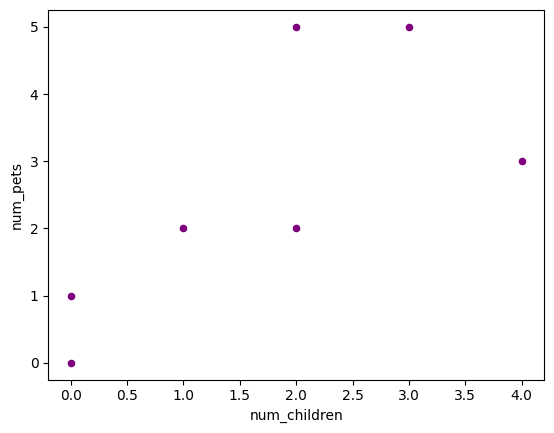

In [13]:
df.plot(kind='scatter',x='num_children',y='num_pets',color='purple');

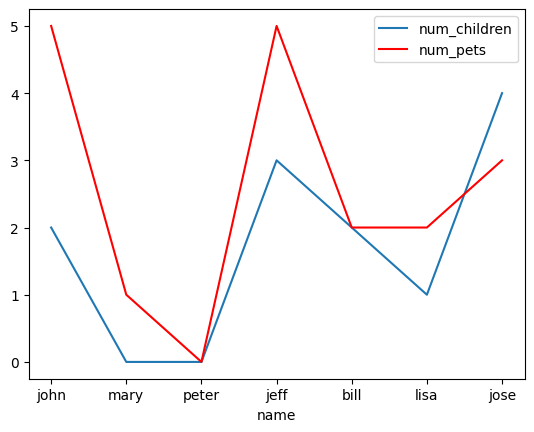

In [14]:
# gca stands for 'get current axis'
ax = plt.gca()
df.plot(kind='line',x='name',y='num_children',ax=ax)
df.plot(kind='line',x='name',y='num_pets', color='red', ax=ax);

#plt.show()

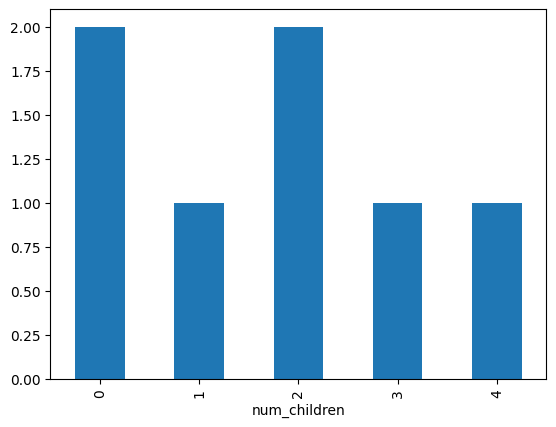

In [15]:
df.groupby('num_children').size().plot(kind='bar');

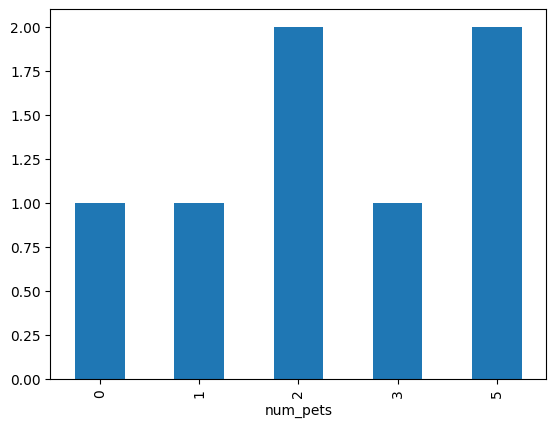

In [16]:
df.groupby('num_pets').size().plot(kind='bar');

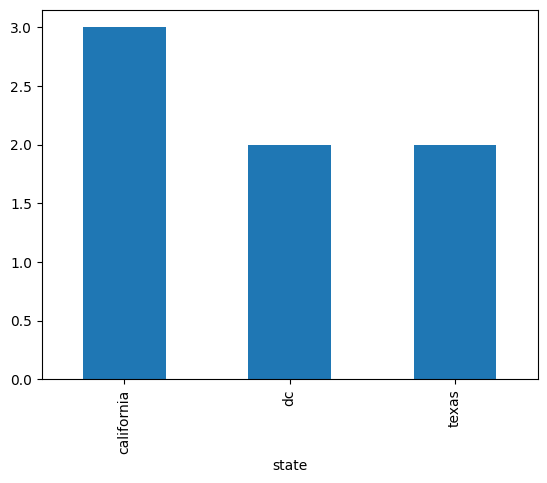

In [19]:
df.groupby('state').size().plot(kind='bar');

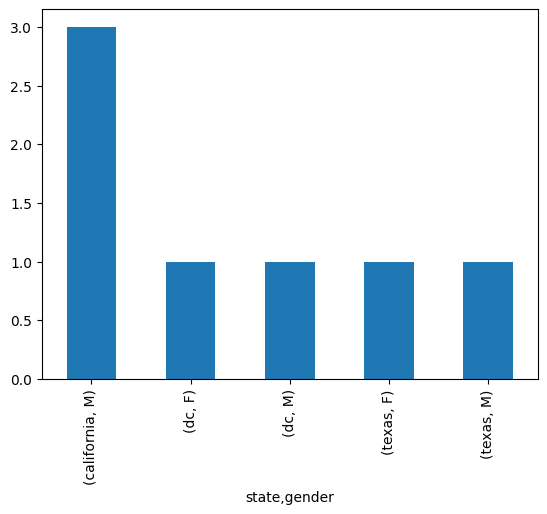

In [20]:
df.groupby(['state','gender']).size().plot(kind='bar');

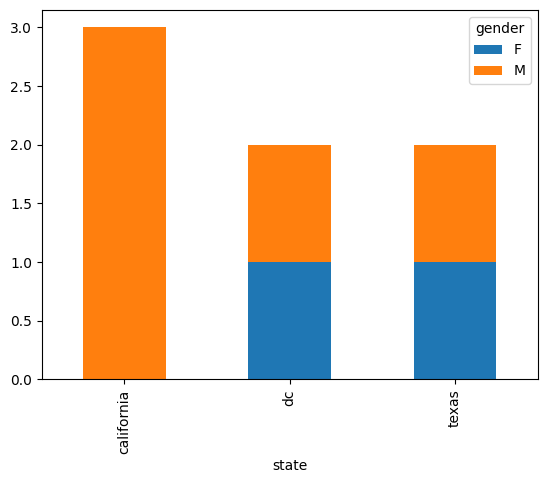

In [21]:
df.groupby(['state','gender']).size().unstack().plot(kind='bar',stacked=True);

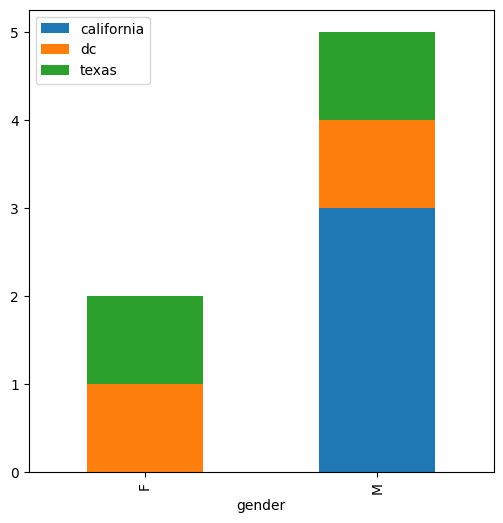

In [22]:
df.groupby(['gender','state']).size().unstack().plot(kind='bar',
                                                     stacked=True,
                                                     figsize=(6, 6))
plt.legend(loc='upper left');

In [30]:
import kagglehub
import os

path = kagglehub.dataset_download("abcsds/pokemon")


print("Path to dataset files:", path)
print(os.listdir(path))

# Load the file with pandas
df = pd.read_csv(f"{path}/Pokemon.csv")
df

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon
['Pokemon.csv']


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True
